In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from pathlib import Path
import pandas as pd
import os

# Caminhos

PROCESSED_DIR = Path("../../../data/Airbnb Prices in European Cities/processed")

train_path = PROCESSED_DIR / "london_treino.csv"
test_path = PROCESSED_DIR / "london_teste.csv"


df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print(df_train.shape, df_test.shape)

(7994, 14) (1999, 14)


In [3]:
TARGET = "realSum"


X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]


X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [4]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def analise_hiperparametros(features, target):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor())
    ])

    search_space = {
        "knn__n_neighbors": Integer(3, 50),
        "knn__weights": Categorical(["uniform", "distance"]),
        "knn__metric": Categorical(["euclidean", "manhattan", "chebyshev"])
    }

    opt = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_space,
        n_iter=25,
        cv=5,
        scoring="neg_mean_squared_error",  
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    opt.fit(features, target)
    return opt


In [5]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def avaliar_modelo(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mse, rmse, r2


MODELO COM FEATURE DAY


In [6]:
grid_day = analise_hiperparametros(X_train, y_train)
best_model_day = grid_day.best_estimator_

print("Melhores hiperparâmetros (com day):")
print(grid_day.best_params_)

mse_day, rmse_day, r2_day = avaliar_modelo(
    best_model_day, X_test, y_test
)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [7]:
print(f"MSE : {mse_day:.4f}")
print(f"RMSE: {rmse_day:.4f}")
print(f"R²  : {r2_day:.4f}")

MSE : 0.0040
RMSE: 0.0636
R²  : 0.6927


MODELO SEM FEATURE DAY

In [8]:
X_train_no_day = X_train.drop(columns=["day"])
X_test_no_day  = X_test.drop(columns=["day"])

grid_no_day = analise_hiperparametros(X_train_no_day, y_train)
best_model_no_day = grid_no_day.best_estimator_

print("Melhores hiperparâmetros (sem day):")
print(grid_no_day.best_params_)

mse_no_day, rmse_no_day, r2_no_day = avaliar_modelo(
    best_model_no_day, X_test_no_day, y_test
)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [9]:
print(f"MSE : {mse_no_day:.4f}")
print(f"RMSE: {rmse_no_day:.4f}")
print(f"R²  : {r2_no_day:.4f}")

MSE : 0.0017
RMSE: 0.0418
R²  : 0.8671


PERMUTATION IMPORTANCE COM DAY

In [10]:
from sklearn.inspection import permutation_importance

result_day = permutation_importance(
    best_model_day,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

importance_day = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_day.importances_mean
}).sort_values("importance", ascending=False)


PERMUTATION IMPORTANCE SEM DAY

In [11]:
X_test_no_day = X_test.drop(columns=["day"])

result_no_day = permutation_importance(
    best_model_no_day,
    X_test_no_day,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

importance_no_day = pd.DataFrame({
    "feature": X_test_no_day.columns,
    "importance": result_no_day.importances_mean
}).sort_values("importance", ascending=False)


GRAFICO COMPARATIVO

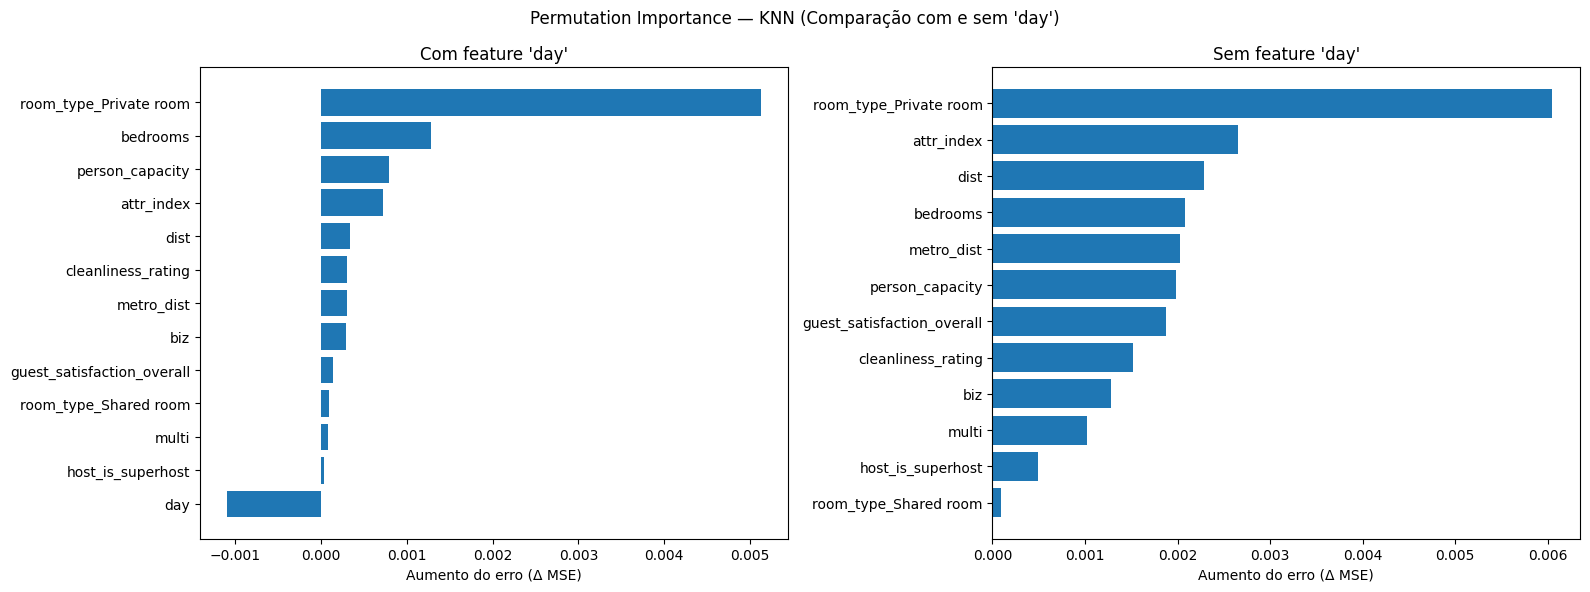

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# ---------- COM day ----------
axes[0].barh(
    importance_day["feature"][:15][::-1],
    importance_day["importance"][:15][::-1]
)
axes[0].set_title("Com feature 'day'")
axes[0].set_xlabel("Aumento do erro (Δ MSE)")

# ---------- SEM day ----------
axes[1].barh(
    importance_no_day["feature"][:15][::-1],
    importance_no_day["importance"][:15][::-1]
)
axes[1].set_title("Sem feature 'day'")
axes[1].set_xlabel("Aumento do erro (Δ MSE)")

plt.suptitle("Permutation Importance — KNN (Comparação com e sem 'day')")
plt.tight_layout()
plt.show()


PERMUTATION IMPORTANCE COM E SEM DAY

In [13]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_day = permutation_importance(
    best_model_day,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_day = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_day.importances_mean
}).sort_values("importance", ascending=False)


In [14]:
X_test_no_day = X_test.drop(columns=["day"])

result_no_day = permutation_importance(
    best_model_no_day,
    X_test_no_day,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_no_day = pd.DataFrame({
    "feature": X_test_no_day.columns,
    "importance": result_no_day.importances_mean
}).sort_values("importance", ascending=False)


GRÁFICO COMPARATIVO

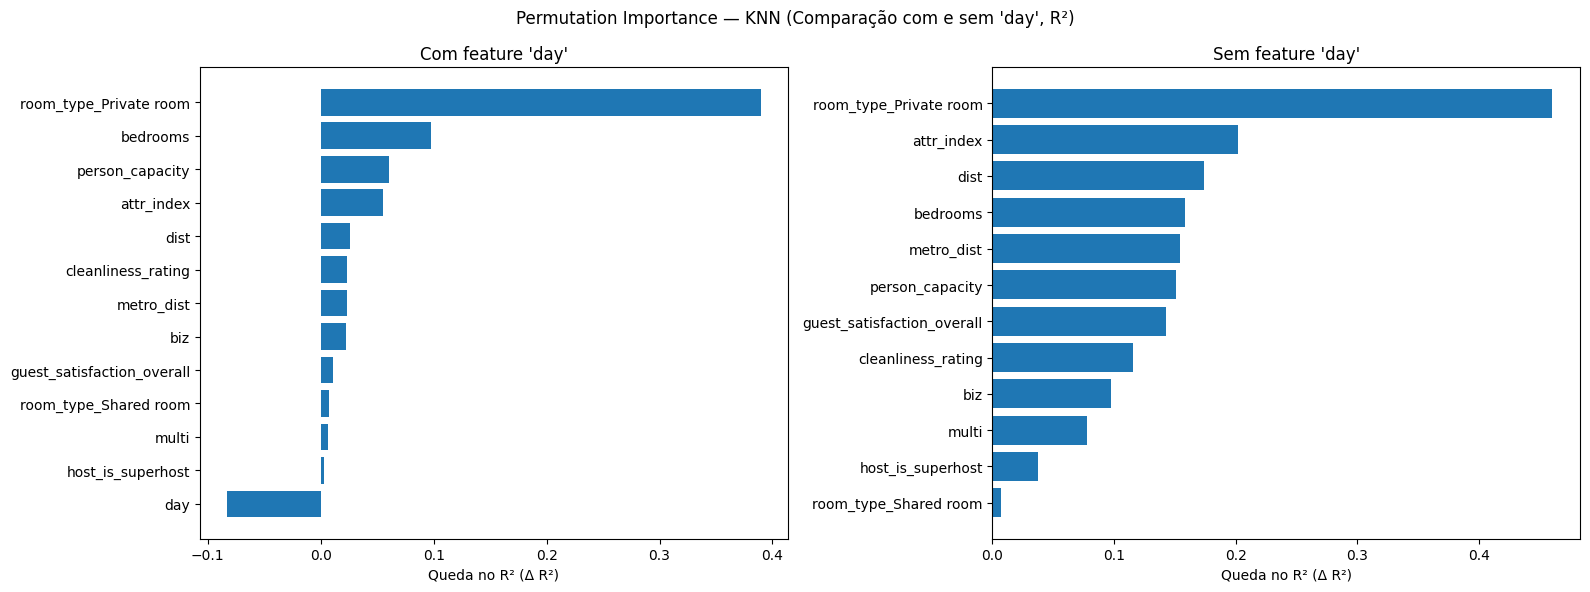

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# ---------- COM day ----------
axes[0].barh(
    importance_day["feature"][:15][::-1],
    importance_day["importance"][:15][::-1]
)
axes[0].set_title("Com feature 'day'")
axes[0].set_xlabel("Queda no R² (Δ R²)")

# ---------- SEM day ----------
axes[1].barh(
    importance_no_day["feature"][:15][::-1],
    importance_no_day["importance"][:15][::-1]
)
axes[1].set_title("Sem feature 'day'")
axes[1].set_xlabel("Queda no R² (Δ R²)")

plt.suptitle("Permutation Importance — KNN (Comparação com e sem 'day', R²)")
plt.tight_layout()
plt.show()
